## Module_3: Fibrosis

## Team Members:
Oge Ikem and Dane Wleklinski

## Project Title:
Using image analysis to interpolate the extent of fibrosis in the lung at different biopsy depths



## Project Goal:
This project seeks to interpolate on a sub-set of lung fibrosis images. Additionally, we want to analyze, conclude, and reflect on the results. 

## Disease Background: 

Idiopathic pulmonary fibrosis (IPF) is a rare, chronic lung disease that causes scarring of the lungs, particularly the alveoli. The thick scar tissue makes it difficult to breathe as it slows the flow of oxygen from the lungs to blood.The exact cause of IPF is unknown; however, researchers believe things breathed in, like wood chips and asbestos, might be linked IPF. One risk factor of IPF is having a relative with the disease, known as familial IPF. Other risk factors include smoking and some infections, like the flu, hepatitis, herpes, and Epstein-Barr virus, but none are direct causes.

The global prevalence of IPF is 0.0177% with North America having a notably higher prevalence of 0.0272%. The global incidence of IPF is 0.0058% with a notably higher incidence in North America of 0.009%. Symptoms of IPF include shortness of breath that gets worse over time, a dry cough that gets worse,aching muscles and joints, extreme tiredness, and clubbing of the tips of fingers and toes. 

There are medications approved to treat IPF, like nerandomilast, nintedanib, and pirfenidone, that work by blocking a process in the lungs that leads to scarring and may help prevent IPF from getting worse. Other medications may be taken in addition to these fight inflammation and slow down the immune system. Oxygen therapy is another treatment for IPF; however, the amount of time and frequency oxygen is needed depends on how severe the condition is. If lung scarring is severe enough, then a lung transplant might be recommended as treatment.

The etiology of IPF begins with repeated injury to the epithelial cells in the alveoli of the lungs. This injury is followed by an abnormal repair process rather than normal healing, where the damaged cells activate fibroblasts and transform them into myofibroblasts. The myofibroblasts produce excessive extracellular matrix, mainly collagen, that leads to progressive scarring and thickening of lung tissue. 

Diagnosis for IPF is difficult because it shares many of the same signs as other lung diseases. Some tests performed are chest scans, to look for shadows that result from scar tissue, breathing tests to measure how well lungs are working, pulse oximetry and blood tests to check oxygen and carbon dioxide levels, and a lung biopsy to check for scarring of lung tissue under a microscope.

## Data-Set: 
The data set used for analysis consists of an unpublished set of 78 black and white images of mouse lungs, recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab in the Division of Pulmonary and Critcal Care at UVA.The data was collected inducing a lung injury to mouse models by giving them Bleomycin, which is primarily used as a chemotherapy. However, a side effect of Bleomycin is lung fibrosis, so it is used to model IPF in these mouse models. After 3 weeks, the mice are sacrificed and their lungs are harvested. The lungs are thinly sliced transversely at various micrometer depths, stained using fluorescently labeled antibodies, and analyzed under a microscope to capture a digital image. The signal of interest is the desmin signal that appears green, and represents the myofibroblasts, the cells that make fibrotic scar tissue. The desmin signal is isolated and converted to a black and white image, where white regions represent fibrotic lesions, and black regions represent healthy lung tissue.



## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*

## Linear Interpolation

Linear interpolation at depth 3000 micron -> 1.837% white


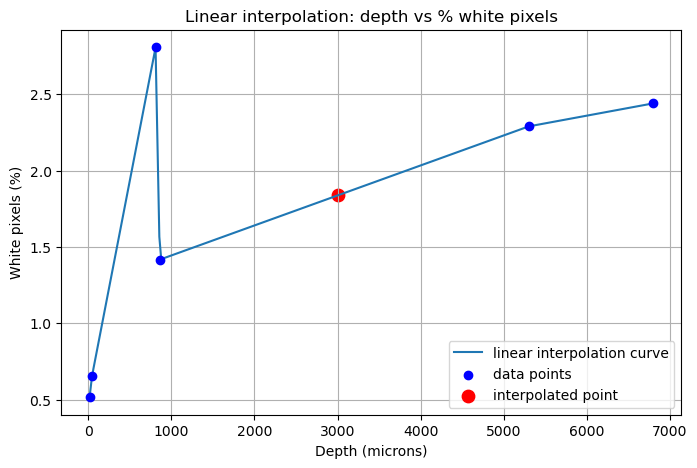

In [1]:
# interpolate using main_example.py
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

try: # get the file 
    df = pd.read_csv('Percent_White_Pixels.csv')
    depths = df['Depths'].tolist()
    white_percents = df['White percents'].tolist()
except FileNotFoundError:
    depths = [45, 810, 15, 5300, 6800, 860]
    white_percents = [83.346, 55.297, 90.101, 37.204, 24.789, 60.112]

x = np.array(depths)
y = np.array(white_percents)

f_linear = interp1d(x, y, kind='linear')

x_interp = np.linspace(x.min(), x.max(), 300)
y_interp = f_linear(x_interp)

# example depth to interpolate
interp_depth = 3000
interp_value = float(f_linear(interp_depth))

print(f"Linear interpolation at depth {interp_depth} micron -> {interp_value:.3f}% white")

plt.figure(figsize=(8,5))
plt.plot(x_interp, y_interp, '-', label='linear interpolation curve')
plt.scatter(x, y, c='blue', label='data points', zorder=5)
plt.scatter([interp_depth], [interp_value], c='red', s=80, label='interpolated point')
plt.title('Linear interpolation: depth vs % white pixels')
plt.xlabel('Depth (microns)')
plt.ylabel('White pixels (%)')
plt.legend()
plt.grid(True)
plt.show()

## Quadratic Interpolation

Quadratic interpolation at depth 3000 micron -> -16.575% white


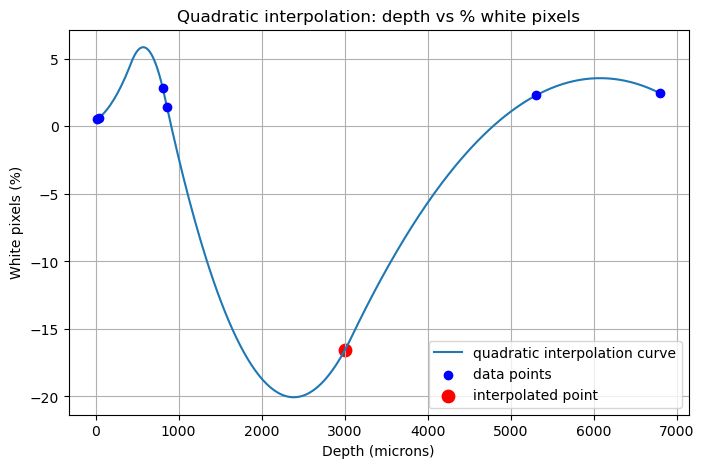

In [ ]:
# Quadratic interpolation
from scipy.interpolate import interp1d 

f_quadratic = interp1d(x, y, kind='quadratic')

x_interp = np.linspace(x.min(), x.max(), 300)
y_interp = f_quadratic(x_interp)

interp_depth = 3000
interp_value = float(f_quadratic(interp_depth))

print(f"Quadratic interpolation at depth {interp_depth} micron -> {interp_value:.3f}% white")

plt.figure(figsize=(8,5))
plt.plot(x_interp, y_interp, '-', label='quadratic interpolation curve')
plt.scatter(x, y, c='blue', label='data points', zorder=5)
plt.scatter([interp_depth], [interp_value], c='red', s=80, label='interpolated point')
plt.title('Quadratic interpolation: depth vs % white pixels')
plt.xlabel('Depth (microns)')
plt.ylabel('White pixels (%)')
plt.legend()
plt.grid(True)
plt.show()

## Cubic Interpolation

Cubic interpolation at depth 3000 micron -> -18.566% white


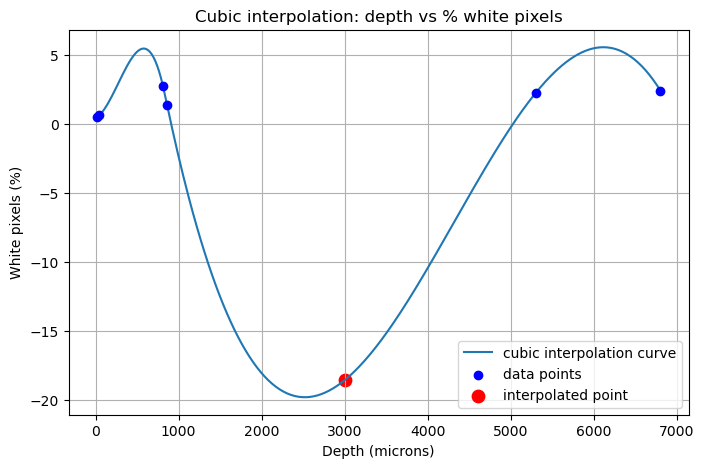

In [3]:
# Cubic interpolation
from scipy.interpolate import interp1d

f_cubic = interp1d(x, y, kind='cubic')

x_interp = np.linspace(x.min(), x.max(), 300)
y_interp = f_cubic(x_interp)

interp_depth = 3000
interp_value = float(f_cubic(interp_depth))

print(f"Cubic interpolation at depth {interp_depth} micron -> {interp_value:.3f}% white")

plt.figure(figsize=(8,5))
plt.plot(x_interp, y_interp, '-', label='cubic interpolation curve')
plt.scatter(x, y, c='blue', label='data points', zorder=5)
plt.scatter([interp_depth], [interp_value], c='red', s=80, label='interpolated point')
plt.title('Cubic interpolation: depth vs % white pixels')
plt.xlabel('Depth (microns)')
plt.ylabel('White pixels (%)')
plt.legend()
plt.grid(True)
plt.show()

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:

Golchin, N., Patel, A., Scheuring, J., Wan, V., Hofer, K., Collet, J. P.,   
Elpers, B., & Lesperance, T. (2025). Incidence and prevalence of idiopathic pulmonary fibrosis: a systematic literature review and meta-analysis. BMC pulmonary medicine, 25(1), 378. https://doi.org/10.1186/s12890-025-03836-1

Wilson, M. S., & Wynn, T. A. (2009). Pulmonary fibrosis: pathogenesis, etiology and regulation. Mucosal immunology, 2(2), 103–121. https://doi.org/10.1038/mi.2008.85

U.S. Department of Health and Human Services. (n.d.). Symptoms. National Heart Lung and Blood Institute. https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis/symptoms 

Watson, S., & Seed, S. (2023, November 7). Idiopathic pulmonary fibrosis: Symptoms, diagnosis, and treatment. WebMD. https://www.webmd.com/lung/what-is-idiopathic-pulmonary-fibrosis 

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 